# Simulation de la Fréquence de Mise à Jour du Modèle de Segmentation

**Objectif** : Déterminer à quelle fréquence le modèle de segmentation client doit être ré-entraîné
pour maintenir des clusters pertinents et stables.

**Méthodologie** :
1. Découper le dataset Olist en fenêtres temporelles (trimestres)
2. Entraîner le modèle sur la première fenêtre (modèle de référence)
3. Appliquer ce modèle aux fenêtres suivantes et mesurer :
   - **Drift des features** (test de Kolmogorov-Smirnov, PSI)
   - **Stabilité des clusters** (ARI entre modèle figé vs ré-entraîné)
   - **Qualité du clustering** (Silhouette Score)
4. Identifier le seuil de dégradation → fréquence de mise à jour recommandée

## 1. Imports et Configuration

In [1]:
import pandas as pd
import numpy as np
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import QuantileTransformer, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from scipy.stats import ks_2samp

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.figsize'] = (14, 6)
matplotlib.rcParams['font.size'] = 11
plt.style.use('seaborn-v0_8-whitegrid')

# Features du modèle
FEATURE_COLS = ['Recency', 'avg_review_score_full', 'avg_delivery_days', 'avg_installments', 'CLV_estimate']
K = 5  # Nombre de clusters
RANDOM_STATE = 42

print("Configuration chargée")
print(f"Features: {FEATURE_COLS}")
print(f"Nombre de clusters K={K}")

Configuration chargée
Features: ['Recency', 'avg_review_score_full', 'avg_delivery_days', 'avg_installments', 'CLV_estimate']
Nombre de clusters K=5


## 2. Chargement et Préparation des Données

In [2]:
# Charger les données brutes avec les timestamps
orders = pd.read_csv('../data/olist_orders_dataset.csv', parse_dates=['order_purchase_timestamp'])
customers = pd.read_csv('../data/olist_customers_dataset.csv')
payments = pd.read_csv('../data/olist_order_payments_dataset.csv')
reviews = pd.read_csv('../data/olist_order_reviews_dataset.csv')
items = pd.read_csv('../data/olist_order_items_dataset.csv')

# Joindre les données
df_raw = orders.merge(customers, on='customer_id', how='left')
df_raw = df_raw.merge(payments.groupby('order_id').agg(
    payment_value=('payment_value', 'sum'),
    payment_installments=('payment_installments', 'max')
).reset_index(), on='order_id', how='left')
df_raw = df_raw.merge(reviews[['order_id', 'review_score']].groupby('order_id')['review_score'].mean().reset_index(), 
                       on='order_id', how='left')

# Calculer delivery_days
df_raw['order_delivered_customer_date'] = pd.to_datetime(df_raw['order_delivered_customer_date'], errors='coerce')
df_raw['delivery_days'] = (df_raw['order_delivered_customer_date'] - df_raw['order_purchase_timestamp']).dt.days

# Ne garder que les commandes livrées avec des données valides
df_raw = df_raw[df_raw['order_status'] == 'delivered'].copy()
df_raw = df_raw.dropna(subset=['order_purchase_timestamp', 'payment_value'])

print(f"Données brutes: {len(df_raw)} commandes livrées")
print(f"Période: {df_raw['order_purchase_timestamp'].min().date()} → {df_raw['order_purchase_timestamp'].max().date()}")

Données brutes: 96477 commandes livrées
Période: 2016-10-03 → 2018-08-29


## 3. Fonction de Feature Engineering par Fenêtre Temporelle

In [3]:
def compute_features_for_window(df_window, snapshot_date):
    """
    Calcule les 5 features du modèle pour une fenêtre temporelle donnée.
    Agrège au niveau client.
    """
    agg = df_window.groupby('customer_unique_id').agg(
        last_order=('order_purchase_timestamp', 'max'),
        frequency=('order_id', 'nunique'),
        monetary=('payment_value', 'sum'),
        avg_review=('review_score', 'mean'),
        avg_delivery=('delivery_days', 'mean'),
        avg_installments=('payment_installments', 'mean'),
    ).reset_index()
    
    # Recency
    agg['Recency'] = (snapshot_date - agg['last_order']).dt.days
    
    # CLV
    duration_years = max((snapshot_date - df_window['order_purchase_timestamp'].min()).days / 365.25, 0.1)
    agg['CLV_estimate'] = agg['monetary'] * (agg['frequency'] / duration_years)
    
    # Renommer
    agg = agg.rename(columns={
        'avg_review': 'avg_review_score_full',
        'avg_delivery': 'avg_delivery_days',
    })
    
    # Remplir NaN
    agg['avg_review_score_full'] = agg['avg_review_score_full'].fillna(agg['avg_review_score_full'].median())
    agg['avg_delivery_days'] = agg['avg_delivery_days'].fillna(agg['avg_delivery_days'].median())
    agg['avg_installments'] = agg['avg_installments'].fillna(agg['avg_installments'].median())
    agg['CLV_estimate'] = agg['CLV_estimate'].fillna(0)
    
    return agg[['customer_unique_id'] + FEATURE_COLS]


def train_pipeline(df_features):
    """Entraîne un pipeline complet (QT → Scaler → PCA → KMeans) et retourne le modèle + données transformées."""
    X = df_features[FEATURE_COLS].values
    
    qt = QuantileTransformer(output_distribution='normal', random_state=RANDOM_STATE)
    X_qt = qt.fit_transform(X)
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_qt)
    
    pca = PCA(n_components=min(4, len(FEATURE_COLS)), random_state=RANDOM_STATE)
    X_pca = pca.fit_transform(X_scaled)
    
    kmeans = KMeans(n_clusters=K, random_state=RANDOM_STATE, n_init=10)
    labels = kmeans.fit_predict(X_pca)
    
    return {
        'qt': qt, 'scaler': scaler, 'pca': pca, 'model': kmeans,
        'labels': labels, 'X_pca': X_pca
    }


def predict_with_pipeline(pipeline, df_features):
    """Applique un pipeline existant (sans ré-entraînement) sur de nouvelles données."""
    X = df_features[FEATURE_COLS].values
    qt_min = pipeline['qt'].quantiles_[0, :]
    qt_max = pipeline['qt'].quantiles_[-1, :]
    X_clamped = np.clip(X, qt_min, qt_max)
    
    X_qt = pipeline['qt'].transform(X_clamped)
    X_scaled = pipeline['scaler'].transform(X_qt)
    X_pca = pipeline['pca'].transform(X_scaled)
    labels = pipeline['model'].predict(X_pca)
    
    return labels, X_pca

print("Fonctions définies ✓")

Fonctions définies ✓


## 4. Découpage en Fenêtres Temporelles (Trimestres)

In [4]:
# Filtrer les mois avec peu de données (sept 2016, sept-oct 2018)
df_raw = df_raw[(df_raw['order_purchase_timestamp'] >= '2017-01-01') & 
                 (df_raw['order_purchase_timestamp'] < '2018-09-01')]

# Créer les fenêtres trimestrielles
df_raw['quarter'] = df_raw['order_purchase_timestamp'].dt.to_period('Q')
quarters = sorted(df_raw['quarter'].unique())

print(f"Fenêtres temporelles: {len(quarters)} trimestres")
for q in quarters:
    mask = df_raw['quarter'] == q
    n_orders = mask.sum()
    n_clients = df_raw[mask]['customer_unique_id'].nunique()
    print(f"  {q}: {n_orders:>6} commandes, {n_clients:>6} clients")

Fenêtres temporelles: 7 trimestres
  2017Q1:   4949 commandes,   4849 clients
  2017Q2:   8984 commandes,   8793 clients
  2017Q3:  12215 commandes,  11931 clients
  2017Q4:  17280 commandes,  16961 clients
  2018Q1:  20627 commandes,  20211 clients
  2018Q2:  19646 commandes,  19391 clients
  2018Q3:  12510 commandes,  12373 clients


## 5. Simulation : Modèle de Référence vs Fenêtres Glissantes

On entraîne le modèle sur le **premier trimestre** (Q1 2017), puis on l'applique 
tel quel sur chaque trimestre suivant pour mesurer la dégradation.

In [5]:
# --- Entraînement du modèle de référence (T0 = Q1 2017) ---
q_ref = quarters[0]
df_ref = df_raw[df_raw['quarter'] == q_ref]
snapshot_ref = df_ref['order_purchase_timestamp'].max() + pd.Timedelta(days=1)
features_ref = compute_features_for_window(df_ref, snapshot_ref)

pipeline_ref = train_pipeline(features_ref)
sil_ref = silhouette_score(pipeline_ref['X_pca'], pipeline_ref['labels'])

print(f"Modèle de référence entraîné sur {q_ref}")
print(f"  Clients: {len(features_ref)}")
print(f"  Silhouette Score: {sil_ref:.4f}")
print(f"  Distribution clusters: {dict(zip(*np.unique(pipeline_ref['labels'], return_counts=True)))}")

Modèle de référence entraîné sur 2017Q1
  Clients: 4849
  Silhouette Score: 0.2352
  Distribution clusters: {np.int32(0): np.int64(647), np.int32(1): np.int64(1106), np.int32(2): np.int64(1258), np.int32(3): np.int64(939), np.int32(4): np.int64(899)}


## 6. Mesure du Drift sur Chaque Fenêtre

In [6]:
results = []

for q in quarters:
    df_q = df_raw[df_raw['quarter'] == q]
    snapshot_q = df_q['order_purchase_timestamp'].max() + pd.Timedelta(days=1)
    features_q = compute_features_for_window(df_q, snapshot_q)
    
    if len(features_q) < 50:
        continue
    
    # --- 1. Drift des features (KS Test) ---
    ks_results = {}
    for col in FEATURE_COLS:
        stat, pvalue = ks_2samp(features_ref[col].values, features_q[col].values)
        ks_results[col] = {'statistic': stat, 'pvalue': pvalue}
    avg_ks = np.mean([v['statistic'] for v in ks_results.values()])
    n_drifted = sum(1 for v in ks_results.values() if v['pvalue'] < 0.05)
    
    # --- 2. Prédiction avec le modèle figé (référence) ---
    labels_frozen, X_pca_frozen = predict_with_pipeline(pipeline_ref, features_q)
    sil_frozen = silhouette_score(X_pca_frozen, labels_frozen) if len(set(labels_frozen)) > 1 else 0
    
    # --- 3. Ré-entraînement sur cette fenêtre ---
    pipeline_new = train_pipeline(features_q)
    sil_retrained = silhouette_score(pipeline_new['X_pca'], pipeline_new['labels'])
    
    # --- 4. ARI entre modèle figé et ré-entraîné ---
    # On compare sur les clients communs
    labels_new, _ = predict_with_pipeline(pipeline_new, features_q)
    ari = adjusted_rand_score(labels_frozen, labels_new)
    
    # --- 5. PSI (Population Stability Index) ---
    def compute_psi(ref_labels, new_labels, n_clusters=K):
        ref_dist = np.array([(ref_labels == c).mean() for c in range(n_clusters)])
        new_dist = np.array([(new_labels == c).mean() for c in range(n_clusters)])
        ref_dist = np.clip(ref_dist, 0.001, None)  # éviter log(0)
        new_dist = np.clip(new_dist, 0.001, None)
        psi = np.sum((new_dist - ref_dist) * np.log(new_dist / ref_dist))
        return psi
    
    psi = compute_psi(pipeline_ref['labels'], labels_frozen)
    
    results.append({
        'quarter': str(q),
        'n_clients': len(features_q),
        'avg_ks_stat': avg_ks,
        'n_features_drifted': n_drifted,
        'silhouette_frozen': sil_frozen,
        'silhouette_retrained': sil_retrained,
        'silhouette_gap': sil_retrained - sil_frozen,
        'ari': ari,
        'psi': psi,
    })
    
    print(f"{q}: KS={avg_ks:.3f} | Drift={n_drifted}/5 | "
          f"Sil(figé)={sil_frozen:.3f} | Sil(retrain)={sil_retrained:.3f} | "
          f"ARI={ari:.3f} | PSI={psi:.4f}")

df_results = pd.DataFrame(results)

2017Q1: KS=0.000 | Drift=0/5 | Sil(figé)=0.235 | Sil(retrain)=0.235 | ARI=1.000 | PSI=0.0000
2017Q2: KS=0.062 | Drift=3/5 | Sil(figé)=0.205 | Sil(retrain)=0.224 | ARI=0.671 | PSI=0.0131
2017Q3: KS=0.078 | Drift=5/5 | Sil(figé)=0.188 | Sil(retrain)=0.226 | ARI=0.591 | PSI=0.0186
2017Q4: KS=0.084 | Drift=5/5 | Sil(figé)=0.204 | Sil(retrain)=0.226 | ARI=0.674 | PSI=0.0491
2018Q1: KS=0.100 | Drift=5/5 | Sil(figé)=0.198 | Sil(retrain)=0.225 | ARI=0.502 | PSI=0.0386
2018Q2: KS=0.086 | Drift=4/5 | Sil(figé)=0.188 | Sil(retrain)=0.215 | ARI=0.363 | PSI=0.0068
2018Q3: KS=0.139 | Drift=5/5 | Sil(figé)=0.244 | Sil(retrain)=0.286 | ARI=0.663 | PSI=0.0654


## 7. Visualisation des Résultats

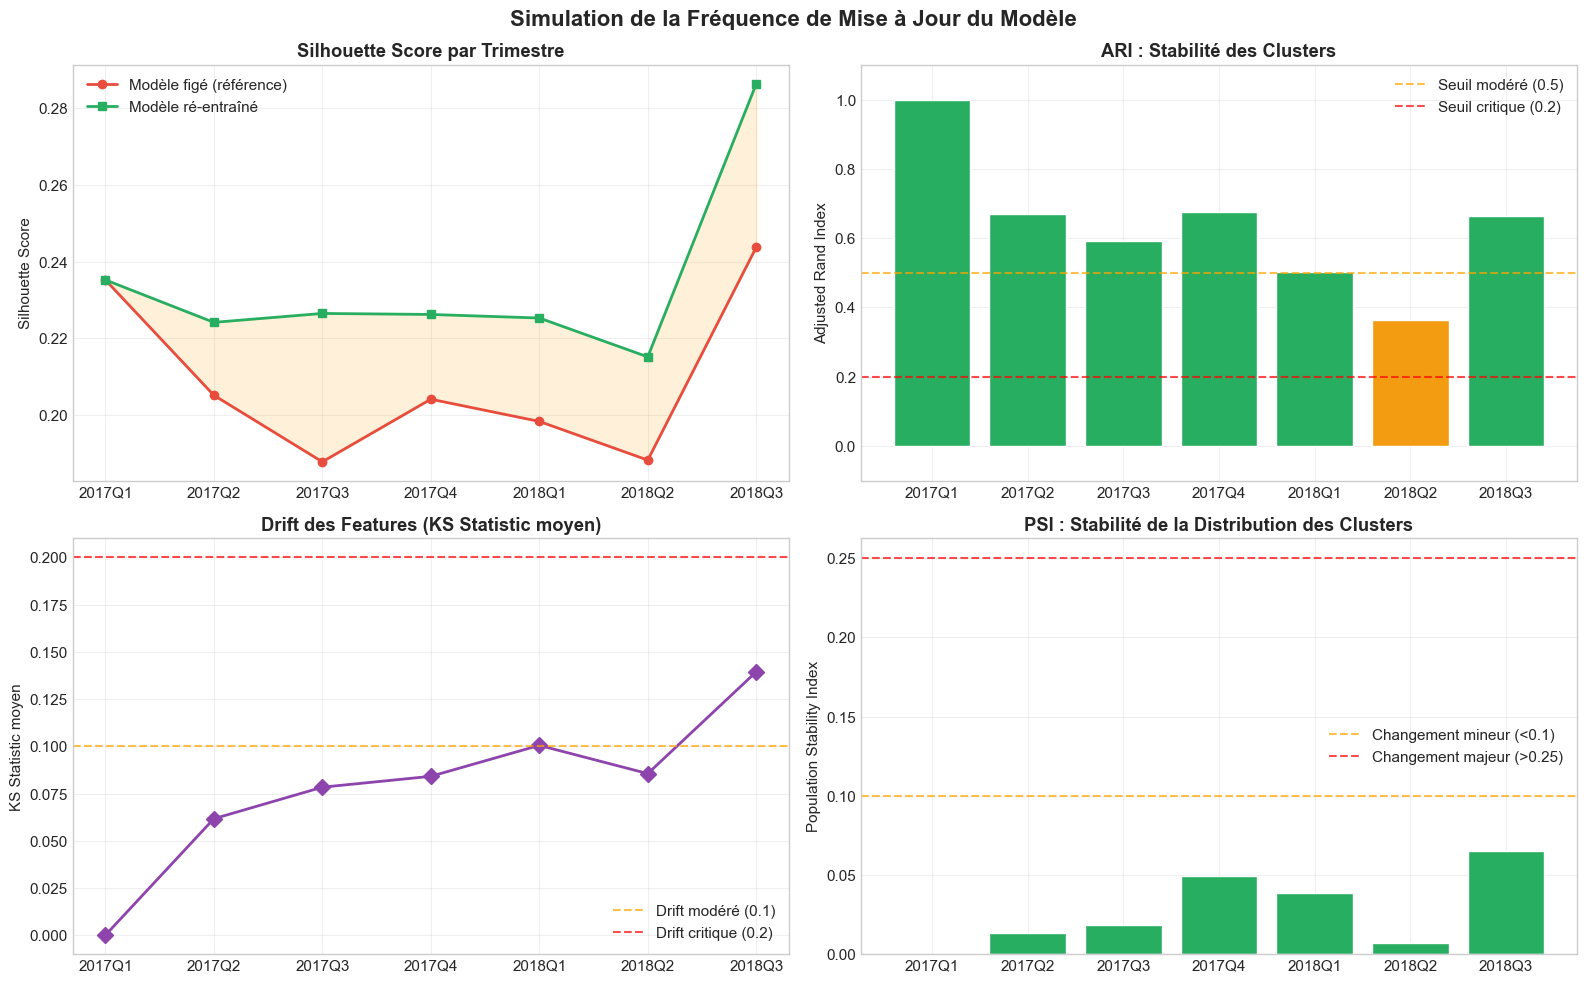

Figure sauvegardée: notebooks/figures/simulation_frequence_maj.png


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Simulation de la Fréquence de Mise à Jour du Modèle', fontsize=16, fontweight='bold')

quarters_labels = df_results['quarter'].values

# --- 7.1 Silhouette Score ---
ax = axes[0, 0]
ax.plot(quarters_labels, df_results['silhouette_frozen'], 'o-', color='#e74c3c', label='Modèle figé (référence)', linewidth=2)
ax.plot(quarters_labels, df_results['silhouette_retrained'], 's-', color='#27ae60', label='Modèle ré-entraîné', linewidth=2)
ax.fill_between(quarters_labels, df_results['silhouette_frozen'], df_results['silhouette_retrained'], alpha=0.15, color='orange')
ax.set_title('Silhouette Score par Trimestre', fontweight='bold')
ax.set_ylabel('Silhouette Score')
ax.legend()
ax.grid(True, alpha=0.3)

# --- 7.2 ARI (stabilité) ---
ax = axes[0, 1]
bars = ax.bar(quarters_labels, df_results['ari'], color=['#27ae60' if a > 0.5 else '#f39c12' if a > 0.2 else '#e74c3c' for a in df_results['ari']], edgecolor='white')
ax.axhline(y=0.5, color='orange', linestyle='--', alpha=0.7, label='Seuil modéré (0.5)')
ax.axhline(y=0.2, color='red', linestyle='--', alpha=0.7, label='Seuil critique (0.2)')
ax.set_title('ARI : Stabilité des Clusters', fontweight='bold')
ax.set_ylabel('Adjusted Rand Index')
ax.legend()
ax.set_ylim(-0.1, 1.1)
ax.grid(True, alpha=0.3)

# --- 7.3 KS Drift ---
ax = axes[1, 0]
ax.plot(quarters_labels, df_results['avg_ks_stat'], 'D-', color='#8e44ad', linewidth=2, markersize=8)
ax.axhline(y=0.1, color='orange', linestyle='--', alpha=0.7, label='Drift modéré (0.1)')
ax.axhline(y=0.2, color='red', linestyle='--', alpha=0.7, label='Drift critique (0.2)')
ax.set_title('Drift des Features (KS Statistic moyen)', fontweight='bold')
ax.set_ylabel('KS Statistic moyen')
ax.legend()
ax.grid(True, alpha=0.3)

# --- 7.4 PSI ---
ax = axes[1, 1]
colors_psi = ['#27ae60' if p < 0.1 else '#f39c12' if p < 0.25 else '#e74c3c' for p in df_results['psi']]
ax.bar(quarters_labels, df_results['psi'], color=colors_psi, edgecolor='white')
ax.axhline(y=0.1, color='orange', linestyle='--', alpha=0.7, label='Changement mineur (<0.1)')
ax.axhline(y=0.25, color='red', linestyle='--', alpha=0.7, label='Changement majeur (>0.25)')
ax.set_title('PSI : Stabilité de la Distribution des Clusters', fontweight='bold')
ax.set_ylabel('Population Stability Index')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../notebooks/figures/simulation_frequence_maj.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure sauvegardée: notebooks/figures/simulation_frequence_maj.png")

## 8. Drift Détaillé par Feature

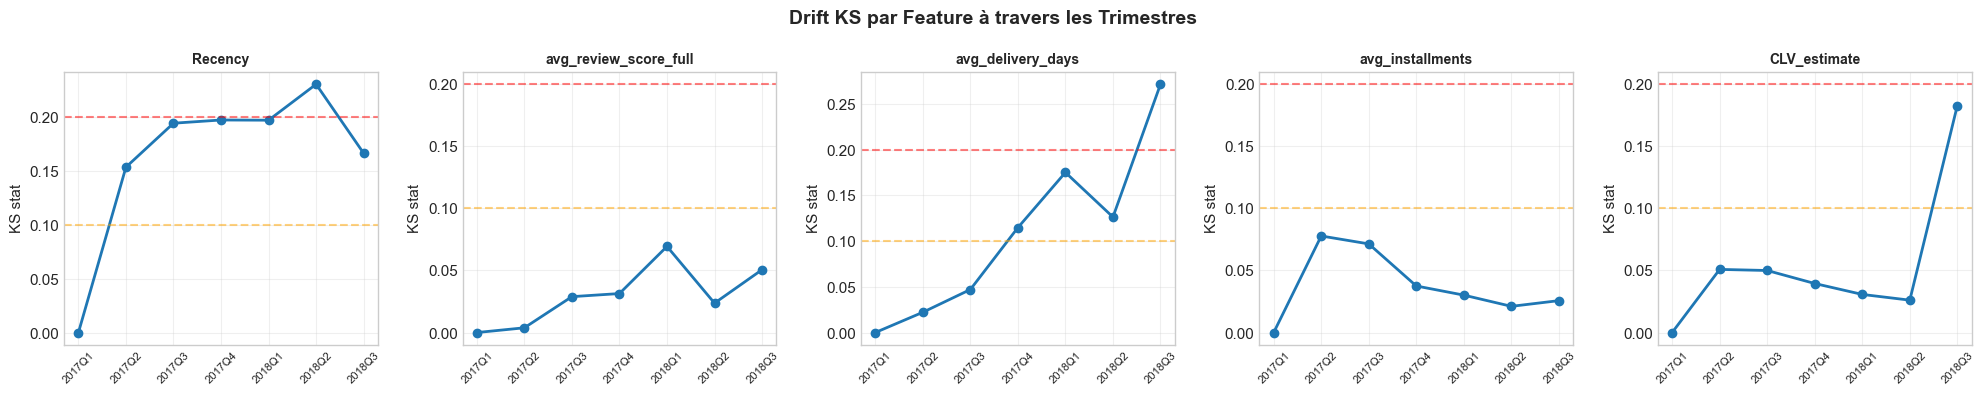

In [8]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle('Drift KS par Feature à travers les Trimestres', fontsize=14, fontweight='bold')

for i, col in enumerate(FEATURE_COLS):
    ax = axes[i]
    ks_values = []
    for q in quarters:
        df_q = df_raw[df_raw['quarter'] == q]
        snapshot_q = df_q['order_purchase_timestamp'].max() + pd.Timedelta(days=1)
        features_q = compute_features_for_window(df_q, snapshot_q)
        if len(features_q) < 50:
            ks_values.append(np.nan)
            continue
        stat, _ = ks_2samp(features_ref[col].values, features_q[col].values)
        ks_values.append(stat)
    
    ax.plot([str(q) for q in quarters], ks_values, 'o-', linewidth=2)
    ax.axhline(y=0.1, color='orange', linestyle='--', alpha=0.5)
    ax.axhline(y=0.2, color='red', linestyle='--', alpha=0.5)
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.set_ylabel('KS stat')
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../notebooks/figures/drift_par_feature.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Tableau Récapitulatif

In [9]:
print("\n" + "=" * 90)
print("TABLEAU RÉCAPITULATIF - SIMULATION FRÉQUENCE DE MISE À JOUR")
print("=" * 90)

df_display = df_results.copy()
df_display['silhouette_gap'] = df_display['silhouette_gap'].apply(lambda x: f"{x:+.4f}")
df_display['recommendation'] = df_display.apply(
    lambda r: 'RETRAINER' if r['ari'] < 0.3 or r['psi'] > 0.25 or r['avg_ks_stat'] > 0.2
    else 'SURVEILLER' if r['ari'] < 0.5 or r['psi'] > 0.1 or r['avg_ks_stat'] > 0.1
    else 'OK', axis=1
)

print(df_display[['quarter', 'n_clients', 'avg_ks_stat', 'silhouette_frozen', 
                   'silhouette_retrained', 'ari', 'psi', 'recommendation']].to_string(index=False))


TABLEAU RÉCAPITULATIF - SIMULATION FRÉQUENCE DE MISE À JOUR
quarter  n_clients  avg_ks_stat  silhouette_frozen  silhouette_retrained      ari      psi recommendation
 2017Q1       4849     0.000000           0.235230              0.235230 1.000000 0.000000             OK
 2017Q2       8793     0.061651           0.205112              0.224140 0.670529 0.013084             OK
 2017Q3      11931     0.078346           0.187730              0.226466 0.590781 0.018566             OK
 2017Q4      16961     0.084095           0.204074              0.226203 0.674470 0.049083             OK
 2018Q1      20211     0.100482           0.198274              0.225274 0.501549 0.038594     SURVEILLER
 2018Q2      19391     0.085538           0.188177              0.215129 0.363372 0.006760     SURVEILLER
 2018Q3      12373     0.139418           0.243748              0.286407 0.662723 0.065387     SURVEILLER


## 10. Conclusion et Recommandation

In [10]:
# Analyse automatique
first_degrade = None
for _, row in df_results.iterrows():
    if row['ari'] < 0.3 or row['psi'] > 0.25 or row['avg_ks_stat'] > 0.2:
        first_degrade = row['quarter']
        break

if first_degrade:
    q_ref_str = str(quarters[0])
    q_idx_ref = [str(q) for q in quarters].index(q_ref_str)
    q_idx_deg = [str(q) for q in quarters].index(first_degrade)
    n_quarters_before_degrade = q_idx_deg - q_idx_ref
    print(f"\n{'=' * 70}")
    print(f"RECOMMANDATION")
    print(f"{'=' * 70}")
    print(f"Le modèle se dégrade significativement après {n_quarters_before_degrade} trimestre(s)")
    print(f"(première dégradation détectée au {first_degrade})")
    print(f"")
    if n_quarters_before_degrade <= 1:
        print(f"→ Fréquence recommandée : MENSUELLE à TRIMESTRIELLE")
    elif n_quarters_before_degrade <= 2:
        print(f"→ Fréquence recommandée : TRIMESTRIELLE (tous les 3 mois)")
    elif n_quarters_before_degrade <= 4:
        print(f"→ Fréquence recommandée : SEMESTRIELLE (tous les 6 mois)")
    else:
        print(f"→ Fréquence recommandée : ANNUELLE")
else:
    print(f"\n{'=' * 70}")
    print(f"RECOMMANDATION")
    print(f"{'=' * 70}")
    print(f"Aucune dégradation critique détectée sur la période analysée.")
    print(f"→ Fréquence recommandée : SEMESTRIELLE avec monitoring continu")

print(f"""
Critères de déclenchement d'un ré-entraînement :
  • ARI < 0.3 (instabilité majeure des clusters)
  • PSI > 0.25 (changement majeur de distribution)  
  • KS moyen > 0.2 (drift significatif des features)
  • Silhouette gap > 0.05 (gain significatif du ré-entraînement)
""")


RECOMMANDATION
Aucune dégradation critique détectée sur la période analysée.
→ Fréquence recommandée : SEMESTRIELLE avec monitoring continu

Critères de déclenchement d'un ré-entraînement :
  • ARI < 0.3 (instabilité majeure des clusters)
  • PSI > 0.25 (changement majeur de distribution)  
  • KS moyen > 0.2 (drift significatif des features)
  • Silhouette gap > 0.05 (gain significatif du ré-entraînement)

